In [1]:
import substrate_depletion_model as sd
import utils as u
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

## Substrate-depletion model
From Size regulated symmetry breaking paper by Scoones et.al. 2020:

$$
\frac{\partial S}{\partial t} = D_s \frac{\partial^2 S}{\partial x^2} + k_{\text{on}}Pf(S) - k_{\text{off}}S
$$

$$
\frac{\partial P}{\partial t} = D_p \frac{\partial^2 P}{\partial x^2} - k_{\text{on}}Pf(S) + k_{\text{off}}S
$$
<!-- $$
\frac{dS}{dt} = k_{\text{on}}Pf(S) - k_{\text{off}}S
$$

$$
\frac{dP}{dt} = - k_{\text{on}}Pf(S) + k_{\text{off}}S
$$ -->

where

$$
f(S) = \frac{S^n}{S_0^n + S^n}
$$

and total amount of $S$ and $P$ is conserved at all times, $t$, scaled linearly with system size, $L$:

$$
N = \int P(x,t) + S(x,t) dx
$$


$$
C = P(t) + S(t)
$$

By linear stability analysis, to achieve equilibrium (from homogenous), the ratio of $P$ to $S$ should tend to:
$$
\frac{P f(S)}{S} = \frac{k_\text{off}}{k_\text{on}}.
$$

or

$$
P/S(\frac{S_0^n}{S^n}+1) = \frac{k_\text{off}}{k_\text{on}}.
$$

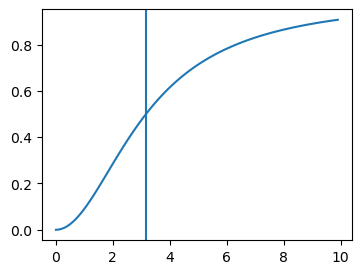

In [2]:
# visualize f sigmoid function
S0 = np.sqrt(10)
S = np.arange(0, 10, 0.1)
plt.figure(figsize=(4,3))
plt.axvline(S0)
plt.plot(S, sd.f(S, n=2, S0=S0))

In [3]:
# Default parameters
D_s = 0.05
D_p = 1    # 1
k_off = 1  # 0.02
k_on = 20*k_off # 0.05
n = 2
S0 = np.sqrt(10)*20 # 0.1

# time
t_steps = 6000
dt = 0.1
T = t_steps*dt
time = np.arange(0, T+dt, t_steps)

# space
dx = 0.05
L = 10
x = np.arange(0, L+dx, dx)

### Vary initial conditions
If start with homogeneous initial conditions without perturbations, then no pattern formation $\forall t, L$. 

If there is initial perturbation, pattern formation depend on length on domain... how?

Total number of molecules 300.


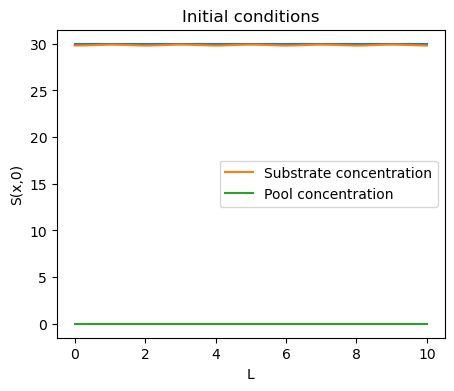

In [4]:
# initial conditions (homogeneous)
N = int(1.5*20*L) # number of molecules
Shom = np.ones_like(x) * N/L
# Si = Shom
# Pi = np.zeros_like(x)

# initial conditions (periodic)
S_shape = (-1/20)*np.cos(10*np.pi*x/L)
k = ((N/dx) - np.sum(S_shape))/len(x)
Si = S_shape + np.ones_like(x)*k
Pi = np.zeros_like(x)
# Pi = np.ones_like(x)*Ptot/L
# N = np.sum(Si*dx + Pi*dx)

# initial conditions (random) (using random number generator from stochastic gillespie method)
# S_num = u.random_int(len(x), N)
# Si = S_num/dx
# Pi = np.zeros_like(x)

plt.figure(figsize=(5,4))
plt.title("Initial conditions")
plt.xlabel("L")
plt.ylabel("S(x,0)")
plt.plot(x, Shom)
plt.plot(x, Si, label="Substrate concentration")
plt.plot(x, Pi, label="Pool concentration")
plt.legend()
print(f"Total number of molecules {N}.")

In [5]:
# # solve with forward euler
# St, Pt = sd.solve_SD_model(Si, 
#                            Pi, 
#                            N,
#                            t_steps=t_steps,
#                            dx=dx)
# #                         dt, 
# #                         dx, 
# #                         t_steps, 
# #                         D_s, 
# #                         D_p, 
# #                         k_on, 
# #                         k_off, 
# #                         n, 
# #                         S0)

# solve with imex method
St, Pt = sd.imex_SD(Si, 
                    Pi, 
                    N,
                    dt=dt,
                    t_steps=t_steps,
#                     D_s=D_s,
#                     D_p=D_p,
#                     kon=k_on,
#                     koff=k_off,
                    n=2,
                    S0=S0)

In [6]:
S_final = round(np.sum(St[:,-1])*dx, 3)
P_final = round(np.sum(Pt[:,-1])*dx, 3)
Total = S_final + P_final

print(f"Total molecule concentration is {Total}.")
print(f"Final substrate molecule concentration is {S_final}.")
print(f"Final pool molecule concentration is {P_final}.")

Total molecule concentration is 300.0.
Final substrate molecule concentration is 213.647.
Final pool molecule concentration is 86.353.


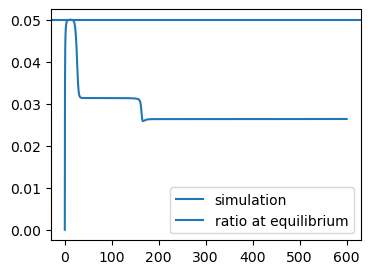

In [7]:
# check ratio at equilibrium
ratio = np.zeros(t_steps+1)
for i in range(t_steps+1):
    P = Pt[:, i]
    S = St[:, i]
    ratio[i] = np.mean([(P[j]*sd.f(S[j], n=2, S0=S0)/S[j]) for j in range(len(P))])
time = np.arange(0, T+dt, dt)
plt.figure(figsize=(4,3))
plt.plot(time, ratio, label="simulation")
plt.axhline(k_off/k_on, label="ratio at equilibrium")
plt.legend()

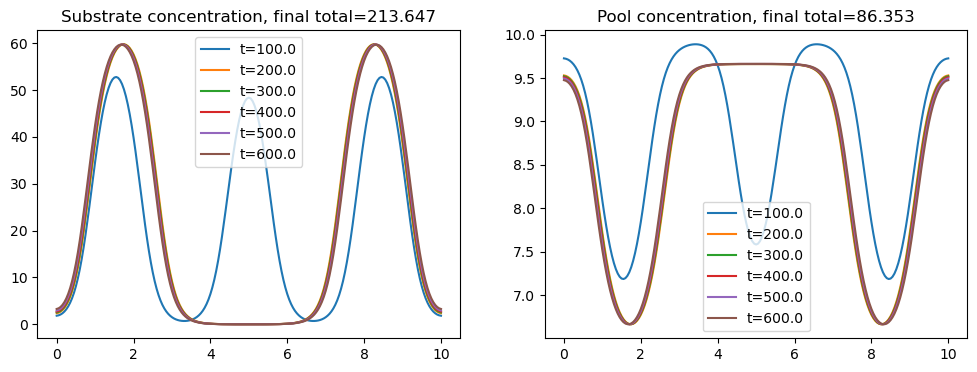

In [8]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
# fig.set_title(f"Concentration after time {T}")
ax[0].set_title(f"Substrate concentration, final total={S_final}")
ax[1].set_title(f"Pool concentration, final total={P_final}")
time = np.arange(0, T+dt, dt)
for t in range(t_steps+1):
    if t!= 0 and time[t]%100==0:
        ax[0].plot(x, St[:, t], label=f"t={time[t]}")
        ax[1].plot(x, Pt[:, t], label=f"t={time[t]}")
ax[0].legend()
ax[1].legend()

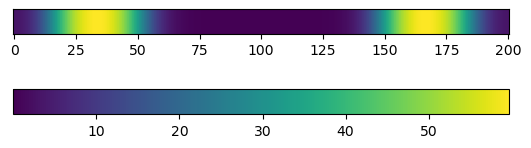

In [9]:
Sfinal = St[:, -1]
# heatmap, xedges, yedges = np.histogram2d(x, Sfinal, bins=(np.linspace(0,x[-1],len(x)+1)))
# extent = [0, x[-1], 1.4, 1.6]
# plt.figure(figsize=(10,3))
# plt.imshow(heatmap.T) #extent=extent, origin='lower', cmap='jet')#,vmin=0, vmax=None)

Smatrix = [Sfinal for i in range(10)]
plt.yticks([])
plt.imshow(Smatrix)
plt.colorbar(location="bottom")

In [10]:
# find the critical system size 
# by simulating with homogeneous initial conditions, 
# find final steady state concentration of S(x,t) and P(x,t)
Shom = 0.89871349 # 0.862
Phom = 0.60128651 # 0.623
dFP = sd.dFdP(Shom, k_on, S0, n)
dFS = sd.dFdS(Shom, Phom, k_on, k_off, S0, n)
Lc = ((2*D_s*D_p)/(D_s*dFP + D_p*dFS))**(1/2)
print(f"Critical length for polarization is {Lc}")

Critical length for polarization is nan


/var/folders/l6/7jpz7klj03q1vh5gplwyx4vm0000gn/T/ipykernel_4225/152316104.py:8: RuntimeWarning: invalid value encountered in scalar power
  Lc = ((2*D_s*D_p)/(D_s*dFP + D_p*dFS))**(1/2)


### Find the order as domain increases in size: 
(Figure 1b)

In [11]:
# time
t_steps = 100000
dt = 0.001
T = t_steps*dt
time = np.arange(0, T+dt, t_steps)
# space
dx = 0.05

In [12]:
lengths = np.array([0.5, 1, 1.5, 2, 3, 4, 5, 6, 8])
order = np.zeros(len(lengths))
# for i in range(len(lengths)):
#     L = lengths[i]
#     x = np.arange(0, L+dx, dx)
#     # initial conditions
#     N = 1.5*L
#     S_shape = (-1/20)*np.cos(2*np.pi*x/L)
#     k = ((N/dx) - np.sum(S_shape))/len(x)
#     Si = S_shape + np.ones_like(x)*k # sinusoidal
#     Pi = np.zeros_like(x)            # always zero
#     # solve
#     St, Pt = sd.solve_SD_model(Si, 
#                                Pi, 
#                                N,
#                                dt=dt,
#                                t_steps=t_steps)
#     order[i] = sd.order_parameter(St[:, -1])

# with open(f"order_parameter.npy", 'wb') as f:
#     np.save(f, order, allow_pickle=True)

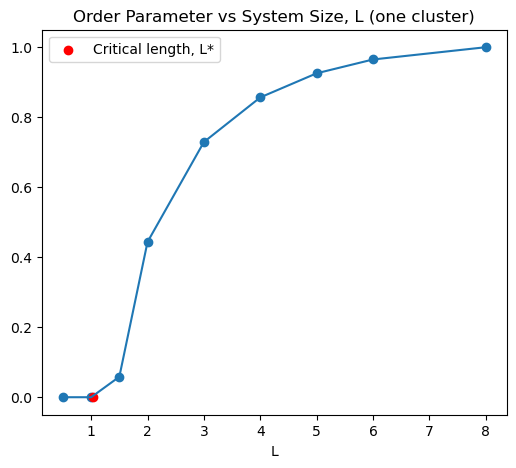

In [13]:
with open(f"order_parameter.npy", 'rb') as f:
    order = np.load(f, allow_pickle=True)

fig = plt.figure(figsize=(6,5))
order_norm = order/order[-1]
plt.title("Order Parameter vs System Size, L (one cluster)")
plt.xlabel("L")
plt.plot(lengths, order_norm)
plt.scatter(lengths, order_norm)
plt.scatter(Lc, 0, color="Red", label="Critical length, L*")
plt.legend()

### Analyse data

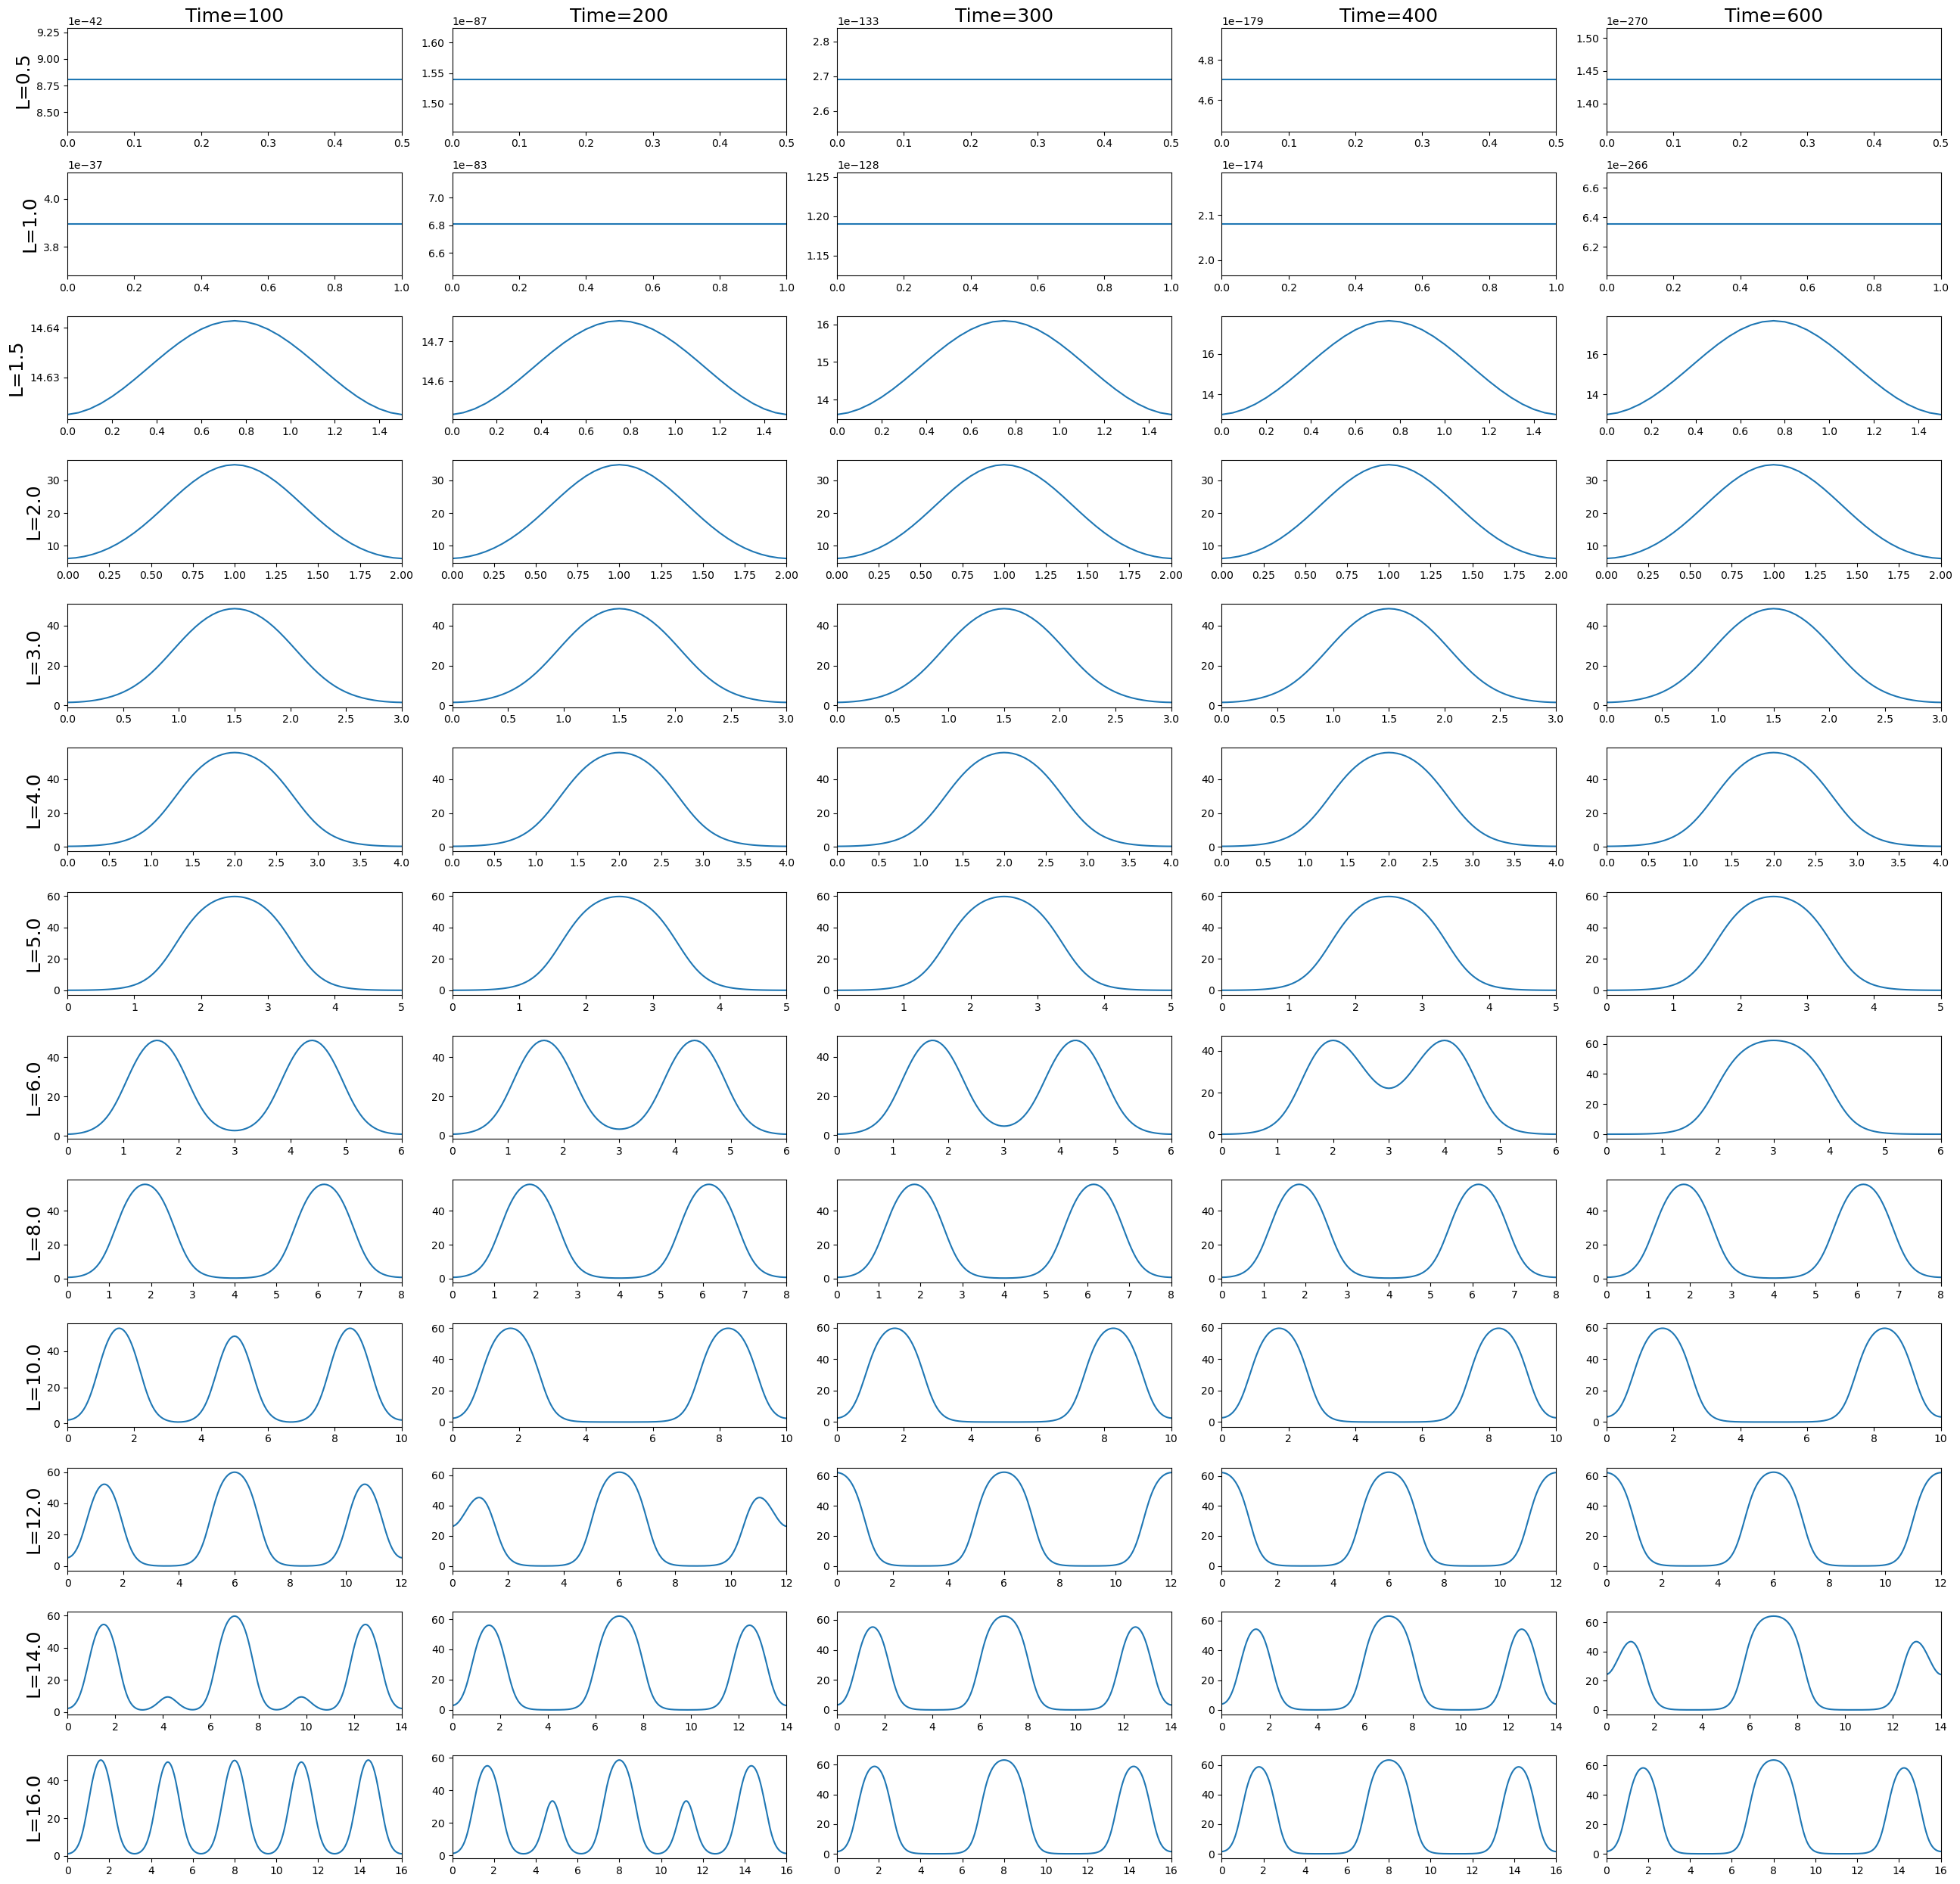

In [15]:
# with original parameters N=1.5*L
# FOLDER = "original_param" # for original parameter version
FOLDER = "imex_scale_N"   # for scaled up version
time = np.array([100, 200, 300, 400, 600])
lengths = np.array([0.5, 1, 1.5, 2, 3, 4, 5, 6, 8, 10, 12, 14, 16])
dx = 0.05

cols = ['Time={}'.format(col) for col in time]
rows = ['L={}'.format(row) for row in lengths]

fig, axes = plt.subplots(nrows=len(lengths), ncols=5, figsize=(26,25))

for ax, col in zip(axes[0], cols):
    ax.set_title(col, fontsize=18)

for ax, row in zip(axes[:,0], rows):
    ax.set_ylabel(row, fontsize=18)

for i in range(len(time)):
    T = time[i]
    for j in range(len(lengths)):
        L = lengths[j]
        
        with open(f"{FOLDER}/final_results_T{T}/substrate_Lf{L}.npy", 'rb') as f:
            Sfinal = np.load(f, allow_pickle=True)
            
        x = np.arange(0, L+dx, dx)
        axes[j][i].plot(x, Sfinal)
        axes[j][i].set_xlim(0, L)
#         axes[j][i].set_ylim()
#         axes[j][i].set_yticks(np.arange(0, 4, 1))

fig.tight_layout()
plt.show()
